# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:

---

## Zestaw zadań 3: Rasterio - dane rastrowe

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx
import rasterio
import rasterio.plot
import rasterio.mask
import affine

In [2]:
# Miejsce do importu pakietów wchodzących w skład standardowej biblioteki Pythona oraz ustawienie opcji wykorzystywanych pakietów

### Wczytanie danych
Poniższy kod wczytuje do zmiennych `districts` oraz `city` dane z pliku data.gpkg.

In [3]:
districts = gpd.read_file("data.gpkg", layer='districts')
districts

,id_dzielni,nr_dzielni,nazwa,nazwa_peln,geometry
0,1,I,Stare Miasto,Dzielnica I Stare Miasto,"POLYGON ((566097.26 244329.716, 566097.477 244..."
1,2,II,Grzegórzki,Dzielnica II Grzegórzki,"POLYGON ((567784.5 244043.139, 567786.287 2440..."
2,16,XVI,Bieńczyce,Dzielnica XVI Bieńczyce,"POLYGON ((571760.606 247243.056, 571777.363 24..."
3,17,XVII,Wzgórza Krzesławickie,Dzielnica XVII Wzgórza Krzesławickie,"POLYGON ((573624.481 247851.831, 573628.378 24..."
4,3,III,Prądnik Czerwony,Dzielnica III Prądnik Czerwony,"POLYGON ((567758.514 246401.517, 567774.358 24..."
5,4,IV,Prądnik Biały,Dzielnica IV Prądnik Biały,"POLYGON ((561609.805 249100.253, 561714.891 24..."
6,18,XVIII,Nowa Huta,Dzielnica XVIII Nowa Huta,"POLYGON ((572690.566 245597.278, 572693.615 24..."
7,5,V,Krowodrza,Dzielnica V Krowodrza,"POLYGON ((563475.506 244986.213, 563476.971 24..."
8,6,VI,Bronowice,Dzielnica VI Bronowice,"POLYGON ((559680.48 247139.293, 559681.829 247..."
9,7,VII,Zwierzyniec,Dzielnica VII Zwierzyniec,"POLYGON ((557355.217 244969.03, 557369.22 2449..."


In [5]:
city = gpd.read_file("data.gpkg", layer='city')
city

,Nazwa,geometry
0,Kraków,"POLYGON ((571937.571 237575.079, 571934.41 237..."


### Zadanie 1: Tworzenie łącza z plikiem i przegląd metadanych (2 pkt)

#### a) Utworzenie łącza z plikiem
Korzystając z funkcji `rasterio.open()` [[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.html#rasterio.open) utwórz łącze z plikiem `NMT.tif` zawierającym numeryczny model terenu miasta Krakowa i jego okolic. Zapisz wynik operacji do zmiennej `dataset`. 

Przeprowadzona operacja nie skutkuje wczytaniem danych rastrowych z pliku - tworzy jedynie obiekt `rasterio.io.BufferedDatasetWriter`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter) zawierający połączenie z plikiem i wczytuje metadane.

In [15]:
dataset = rasterio.open('NMT.tif')

In [16]:
# Komórka testowa
assert type(dataset) == rasterio.io.DatasetReader

#### b) Przegląd metadanych
Korzystając z własności `rasterio.io.BufferedDatasetWriter.meta` wyświetl podstawowe informacje o zestawie danych.

Przejrzyj wyświetlone dane - część z tych informacji może się przydać w kolejnych zadaniach:
 - driver: format pliku
 - dtype: typ danych (`int`, `float`)
 - nodata: oznaczenie braku danych (None oznacza domyślną wartość `np.nan`, dla danych w formacie `int` jest to najczęściej wartość `-9999`)
 - width: szerokość rastra
 - height: wysokość rastra
 - count: liczba wartstw w rastrze
 - crs: układ odniesienia
 - transform: transformacja pozwalająca na georeferencję rastra (zawiera informacje o przekształceniu, współrzędnych lewego górnego narożnika rastra oraz wielkości piksela).

In [17]:
dataset.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 6273,
 'height': 4178,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["ETRF2000-PL / CS92",GEOGCS["ETRF2000-PL",DATUM["ETRF2000_Poland",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1305"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","9702"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",19],PARAMETER["scale_factor",0.9993],PARAMETER["false_easting",500000],PARAMETER["false_northing",-5300000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","2180"]]'),
 'transform': Affine(5.0, 0.0, 555875.5,
        0.0, -5.0, 253571.5)}

Korzystając z własności `rasterio.io.BufferedDatasetWriter.descriptions` wyświetl opis warstw rastra. 

In [18]:
dataset.descriptions

('Wysokość m n.p.m',)

Na potrzeby rozwiązania kolejnych zadań warto zapamiętać, że dostęp do każdej z metadanych oraz wielu innych własności rastra można uzyskać w ten sam sposób co do wyświetlonego wyżej opisu warstw, np. znajdujący się w metadanych parametr count (liczba wartstw w rastrze) można wywołać jako `rasterio.io.BufferedDatasetWriter.count`.

### Zadanie 2: Wczytywanie i wizualizacja danych (3 pkt)

Wczytanie danych do pamięci operacyjnej następuje dopiero w momencie wykorzystania funkcji `rasterio.io.BufferedDatasetWriter.read()` lub funkcji odpowiedzialnych za wyświetlanie danych rastrowych - `rasterio.plot.show()`, `rasterio.plot.show_hist()`. Proces ten jest oddzielony od procesu tworzenia łacza z plikim ze względu na potencjalnie dużą objętość danych w nim zawartych. Funkcje służące do wczytywania danych dają możliwość określenia, który fragment danych ma zostać w danym momencie wczytany. Dane załączone do tego notatnika są jednak na tyle małe objętościowo, że w zadanich nie będzie konieczności określania wartości odpowiedzialnych za to argumentów.

#### a) Wczytywanie danych
Za pomocą funkcji `rasterio.io.BufferedDatasetWriter.read()`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.read) wczytaj do zmiennej `NMT_array` pojedynczą warstwę zawierającą numeryczny model terenu. W tym celu należy określić numer wartstwy (1, 2, 3...), wywołanie funkcji bez argumentów spowoduje wczytanie wszystkich warstw w postaci macierzy 3D. Wyświetl przygotowaną zmianną.

In [25]:
NMT_array = dataset.read(indexes = 1)
NMT_array

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4178, 6273), dtype=float32)

In [26]:
# Komórka testowa
assert type(NMT_array) == np.ndarray
assert np.shape(NMT_array) == (4178, 6273)
assert np.sum(np.isnan(NMT_array)) == 7367049
assert np.isclose(np.nanmin(NMT_array), 185.91194)
assert np.isclose(np.nanmean(NMT_array), 227.67537)
assert np.isclose(np.nanmax(NMT_array), 382.4375)

#### b) Wizualizacja danych

Korzystając z funkcji pakietów matplotlib, geopandas i contextily oraz funkcji `rasterio.plot.show()`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.plot.html#rasterio.plot.show) i `rasterio.plot.show_hist()`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.plot.html#rasterio.plot.show_hist) przygotuj figurę (siatka wykresów 2x1) zawierającą następujące wykresy:

Wykres 1 (warstwy idąc od spodu):
- samodzielnie wybrana (inną od domyślnej) mapa podkładowa,
- raster z numerycznym modelem terenu, samodzielnie dobraną, inną od domyślnej skalą kolorów, której zakres wartości wynosi 0-400 (argumenty `vmin` i `vmax`),
- kontury dzielnic miasta Krakowa, bez wypełnienia.

Wykres 2:
- histogram wysokości zawierający przedziały o szerokości 2 w zakresie wartości 180-380 (argument `bins`)

W obu przypadkach jako źródło danych wskaż zmienną `dataset` - jest to pełny zestaw danych zawierający w sobie informację o transformację i eliminuję potrzebę jej osobnej definicji podczas wywołania funkcji.

Przygotowując figurę pamiętaj o ogólnych wytycznych z nagłówka notatnika.

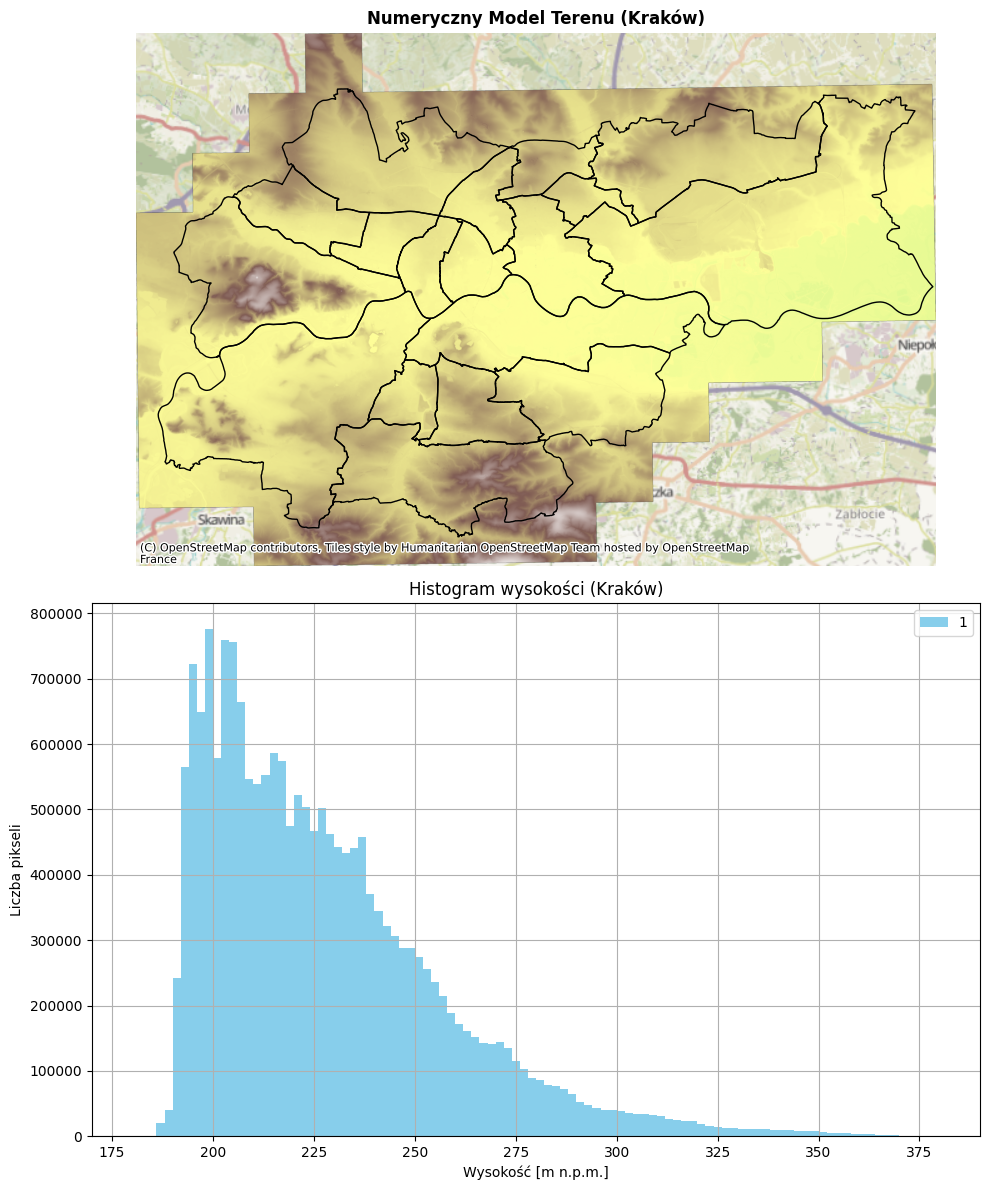

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
rasterio.plot.show(dataset, ax=ax1, cmap='terrain', vmin=0, vmax=400, title="Numeryczny Model Terenu (Kraków)", zorder = 2)
districts.to_crs(dataset.crs).boundary.plot(ax=ax1, color='black', linewidth=1, zorder=3)
cx.add_basemap(ax1, crs=dataset.crs.to_string(), zorder=1)
ax1.set_axis_off()
rasterio.plot.show_hist(dataset, bins=range(180, 382, 2), lw=0.0, facecolor='skyblue', edgecolor='black', ax=ax2)
ax2.set_title("Histogram wysokości (Kraków)")
ax2.set_xlabel("Wysokość [m n.p.m.]")
ax2.set_ylabel("Liczba pikseli")

plt.tight_layout()
plt.show()

### Zadanie 3: Próbkowanie rastra (2 pkt)

Korzystając z własności `geopandas.GeoSeries.centroid` oraz funkcji `rasterio.io.DatasetReaderBase.sample()`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.sample) wyznacz wysokość terenu w centralnym punkcie każdej z dzielnic. Zapisz wyniki do tablicy `districts` w kolumnie o nazwie "Wysokość w centroidzie", 

Przykładowy schemat rozwiązania zadania można znaleźć w dokumentacji pakietu GeoPandas [[LINK]](https://geopandas.org/en/stable/gallery/geopandas_rasterio_sample.html#Sampling-the-data)
Zwróć uwagę, że przedstawiony schemat w wyniku próbkowania zestawu danych rasterio zwracane każdorazowo macierz zawierającą wyniki próbkowania dla wszystkich warstw rastra. Zmodyfikuj rozwiązanie z przykładu tak, aby wynikiem próbkowania dla każdej dzielnicy była pojedyncze wartość (`float`).

In [92]:
centroidy = districts.centroid
coord_list = [(x, y) for x, y in zip(centroidy.x, centroidy.y)]
g = [x[0] for x in dataset.sample(coord_list)]
districts["Wysokość w centroidzie"] = g
districts

,id_dzielni,nr_dzielni,nazwa,nazwa_peln,geometry,Wysokość w centroidzie
0,1,I,Stare Miasto,Dzielnica I Stare Miasto,"POLYGON ((566097.26 244329.716, 566097.477 244...",213.597031
1,2,II,Grzegórzki,Dzielnica II Grzegórzki,"POLYGON ((567784.5 244043.139, 567786.287 2440...",201.936890
2,16,XVI,Bieńczyce,Dzielnica XVI Bieńczyce,"POLYGON ((571760.606 247243.056, 571777.363 24...",223.854156
3,17,XVII,Wzgórza Krzesławickie,Dzielnica XVII Wzgórza Krzesławickie,"POLYGON ((573624.481 247851.831, 573628.378 24...",227.650101
4,3,III,Prądnik Czerwony,Dzielnica III Prądnik Czerwony,"POLYGON ((567758.514 246401.517, 567774.358 24...",219.655777
5,4,IV,Prądnik Biały,Dzielnica IV Prądnik Biały,"POLYGON ((561609.805 249100.253, 561714.891 24...",230.757004
6,18,XVIII,Nowa Huta,Dzielnica XVIII Nowa Huta,"POLYGON ((572690.566 245597.278, 572693.615 24...",206.276886
7,5,V,Krowodrza,Dzielnica V Krowodrza,"POLYGON ((563475.506 244986.213, 563476.971 24...",206.712769
8,6,VI,Bronowice,Dzielnica VI Bronowice,"POLYGON ((559680.48 247139.293, 559681.829 247...",225.793198
9,7,VII,Zwierzyniec,Dzielnica VII Zwierzyniec,"POLYGON ((557355.217 244969.03, 557369.22 2449...",307.745880


In [94]:
# Komórka testowa
assert districts.shape == (18, 6)
assert np.isclose(districts["Wysokość w centroidzie"].min(), 199.486572265625)
assert np.isclose(districts["Wysokość w centroidzie"].mean(), 228.1379369099935)
assert np.isclose(districts["Wysokość w centroidzie"].max(), 307.7458801269531)

### Zadanie 4: Docinanie rastra do poligonu i wizualizacja danych (4 pkt)

#### a) Docinanie rastra
Korzystając z funkcji  `rasterio.mask.mask()`[[LINK]](https://rasterio.readthedocs.io/en/stable/api/rasterio.mask.html#rasterio.mask.mask) dotnij raster do granic miasta Krakowa. Ustaw argumenty funkcji tak, aby:
 - wartości rastra poza granicami miasta były ustawione na `numpy.nan`,
 - rozmiar rastra był docięty do zakresu współrzędnych miasta Krakowa.

Zwróć uwagę, że funkcja zwraca dwie zmienne - zmodyfikowany raster (macierz numpy) i transformację tego rastra (ponieważ w wyniku tej operacji mogą ulec zmianie wymiary rastra, zmianie ulega również transformacja). Zapisz wyniki odpowiednio do zmiennych `NMT_krk` i `transform_krk`.

In [98]:
NMT_krk, transform_krk = rasterio.mask.mask(dataset, shapes = city["geometry"], nodata=np.nan, crop=True)
NMT_krk

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 3513, 6075), dtype=float32)

In [97]:
# Komórka testowa
assert type(NMT_krk) == np.ndarray
assert np.shape(NMT_krk) == (1, 3513, 6075)
assert np.sum(np.isnan(NMT_krk)) == 8284377
assert np.isclose(np.nanmin(NMT_krk), 185.91194)
assert np.isclose(np.nanmean(NMT_krk),222.44868)
assert np.isclose(np.nanmax(NMT_krk), 382.4375)
assert type(transform_krk) == affine.Affine

#### b) Wizualizacja danych

Przygotuj figurę identyczną jak ta w zadaniu 2b, ale tym razem w oparciu o docięte dane. Zwróć uwagę, że w tym przypadku nie dysponujemy kompletnym zestawem danych tylko osobnymi zmiennymi z macierzą numpy i transformacją. Funkcje `rasterio.plot.show()` i `rasterio.plot.show_hist()` mogą przyjąć jako źródło danych zarówno pełny zestaw danych jak i macierz numpy. W drugim z przypadków funkcja `rasterio.plot.show()` wymaga jednak dodatkowo określenia argumentu `transform` w celu georeferencji danych z macierzy.

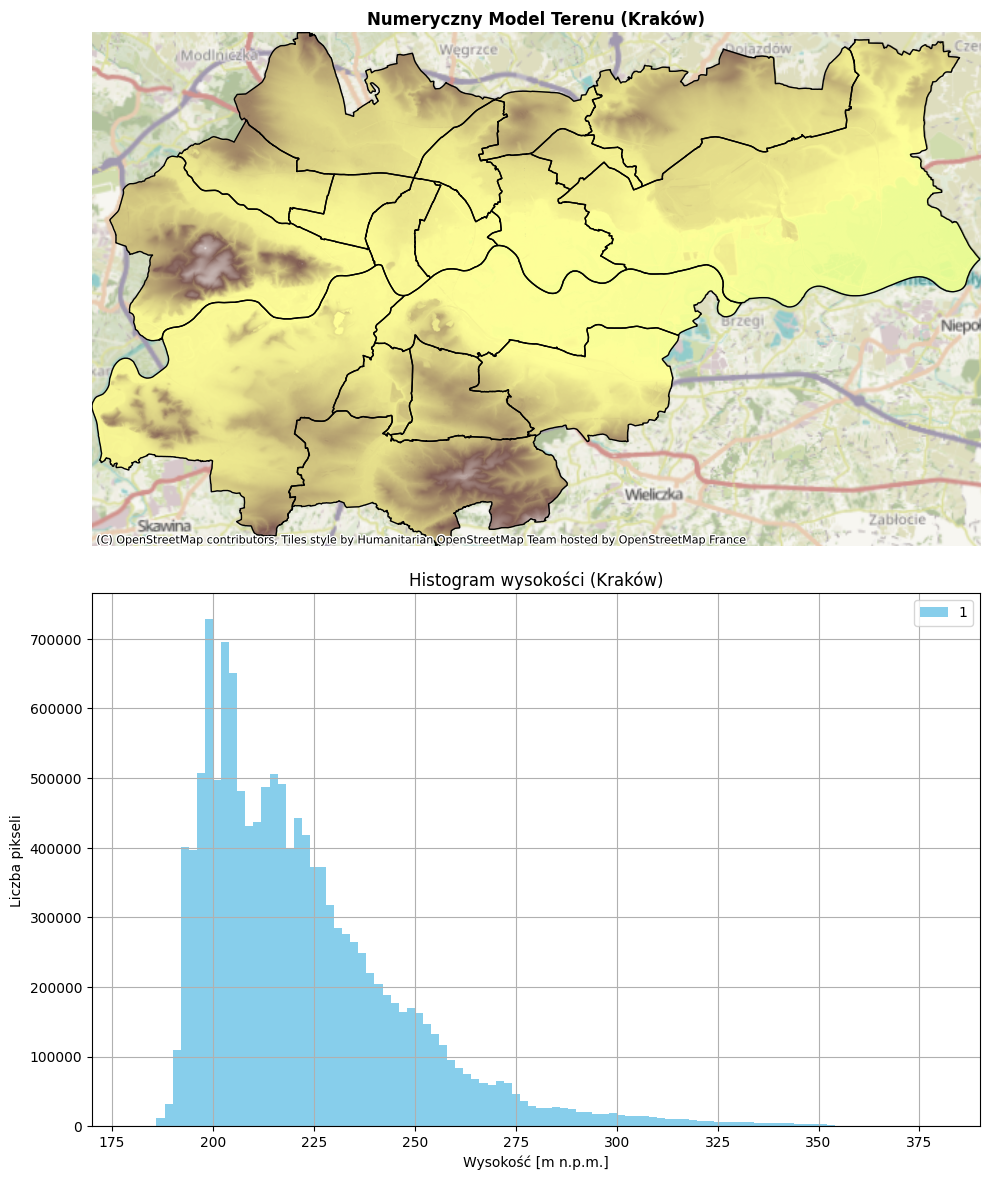

In [99]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

rasterio.plot.show(NMT_krk[0], ax=ax1, transform=transform_krk, cmap='terrain',
                   vmin=0, vmax=400, title="Numeryczny Model Terenu (Kraków)", zorder=2)

districts.boundary.plot(ax=ax1, color='black', linewidth=1, zorder=3)

cx.add_basemap(ax1, crs=dataset.crs.to_string(), zorder=1)

ax1.set_axis_off()

rasterio.plot.show_hist(NMT_krk[0], bins=range(180, 382, 2), lw=0.0,
                        facecolor='skyblue', edgecolor='black', ax=ax2)

ax2.set_title("Histogram wysokości (Kraków)")
ax2.set_xlabel("Wysokość [m n.p.m.]")
ax2.set_ylabel("Liczba pikseli")

plt.tight_layout()
plt.show()

### Zadanie 5: Analiza rozkładu wysokości na terenie miasta Krakowa (10 pkt)

W poprzednich zadaniach funkcja `rasterio.plot.show_hist()` została wykorzystana do wykonania histogramu rozkładu wysokości w obrębie całego miasta. Celem tego zadania jest zobrazowanie rozkładu wysokości w obrębie poszczególnych dzielnic.

#### a) Przygotowanie danych do wykresów 

Przygotuj i wyświetl tablicę `plot_data` zawierająca wyłącznie następujące elementy:</br>

> Indeks:</br>
> Domyślny indeksowanie tablicy

> Kolumny: Wysokość, Dzielnica</br>
> Kolumny zawierające wysokości pikseli rastra oraz inforamację do której dzielnicy należy dany piksel

Przykładowy schemat rozwiązania:
 1) Przygotuj zmienną zawierającą pustą listę.
 2) Przygotuj pętlę `for` iterującą po indeksach tablicy zawierającej informacje o dzielnicach Krakowa - możesz ustawić iterator manualnie lub wykorzystać własność tablicy `pandas.DataFrame.index`. W obrębie pętli `for`:
    - Korzystając z własności tablicy `pandas.DataFrame.loc` lub `pandas.DataFrame.iloc` lub z metody logicznej selekcji po kolumnie atrybutowej wybierz wiersz tablicy dotyczący konkretnej dzielnicy (w każdej iteracji pętli będzie to inna dzielnica).
    - Korzystając z funkcji `rasterio.mask.mask()` dotnij raster do granic dzielnicy. Ustaw argumenty funkcji tak aby wartości rastra poza granicami dzielnicy były ustawione na `numpy.nan`, a rozmiar rastra był docięty do zakresu współrzędnych dzielnicy.
    - Spłaszcz wynikową macierz korzystając z funkcji `numpy.ndarray.flatten()` i zbuduj na jej podstawie tablicę Pandas z kolumnami: "Wysokość" (wysokości pikseli) oraz "Dzielnica" (nazwa dzielnicy do której należą piksele). Nazwę dzielnicy możesz dodać jako skalar, nie ma potrzeby dopisywania tej samej nazwy do każdego z pikseli osobno.
    - Korzystając z funkcji `pandas.DataFrame.dropna()` usuń wiersze tablicy zawierające wartości `numpy.nan`.
    - Dodaj tablicę do przygotowanej przed pętlą listy.

 3) Korzystając z funkcji `pandas.concat()` połącz zawarte w liście tablice w całość. Pamiętaj o odpowiednim ustawieniu wartości argumentu `axis`.
 4) Zresetuj indeks tablicy.
 5) Wyświetl wynikową tablicę.

In [129]:
l = []
for i in districts.index:
    temp1, temp2 = rasterio.mask.mask(dataset, [districts.loc[i, 'geometry']], nodata=np.nan, crop=True)
    temp1 = temp1[0].flatten()
    df = pd.DataFrame({
        "Wysokość": temp1,
        "Dzielnica": districts.loc[i, 'nazwa']
    })
    df.dropna(inplace = True)
    l.append(df)
plot_data = pd.concat(l)
plot_data.reset_index(inplace = True, drop = True)
plot_data

    

,Wysokość,Dzielnica
0,213.034119,Stare Miasto
1,213.387543,Stare Miasto
2,214.021317,Stare Miasto
3,214.639771,Stare Miasto
4,215.178482,Stare Miasto
...,...,...
13057091,219.271057,Mistrzejowice
13057092,219.247086,Mistrzejowice
13057093,219.156921,Mistrzejowice
13057094,219.124374,Mistrzejowice


In [130]:
# Komórka testowa
assert type(plot_data) == pd.core.frame.DataFrame
assert plot_data.shape == (13057096, 2)
assert list(plot_data.columns) == ['Wysokość', 'Dzielnica']
assert np.isclose(plot_data['Wysokość'].min(), 185.91194)
assert np.isclose(plot_data['Wysokość'].mean(), 222.4487)
assert np.isclose(plot_data['Wysokość'].max(), 382.4375)

#### b) Histogram 

Korzystając z funkcji `seaborn.histplot()`, przygotuj histogram rozkładu wysokości terenu w granicach miasta Krakowa z podziałem na poszczególne dzielnice. Ustaw argumenty wykresu tak, aby:
 - histogram składał się z przedziałów o szerokości 2, obejmujących zakres wartości od 180 do 380,
 - mierzoną cechą była częstość względna (proporcja),
 - był to histogram warstwowy - wartości z różnych dzielnic były nakładane pionowo w tych samych przedziałach klasowych, a każdy słupek przedstawiał łączną proporcję rozbitą kolorami na udziały poszczególnych dzielnic,
 - zastosowana paleta kolorów była inna niż domyślna,
 - w obrębie wykresu znajdowała się legenda.

Przygotowując figurę pamiętaj o ogólnych wytycznych z nagłówka notatnika.

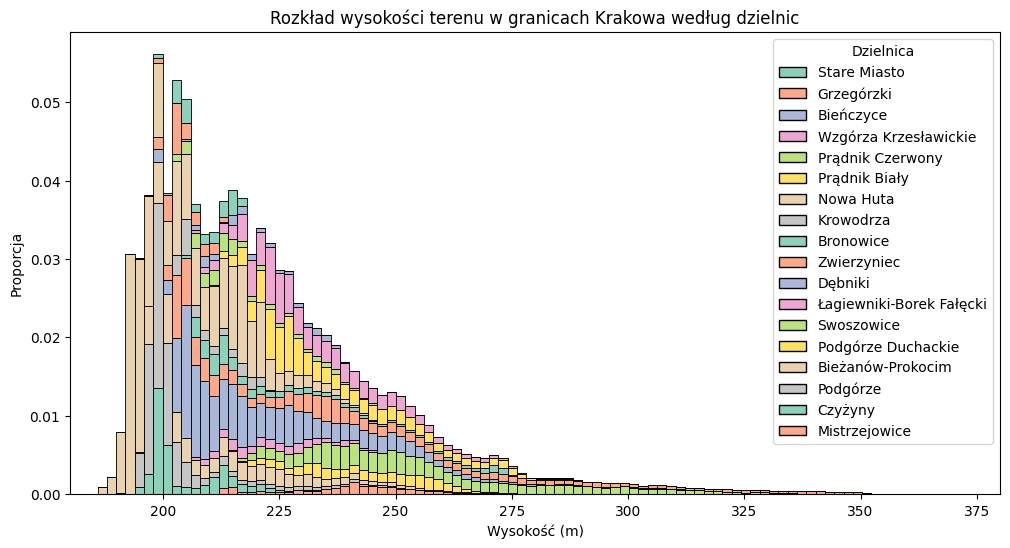

In [138]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=plot_data,
    x='Wysokość',
    hue='Dzielnica', 
    multiple='stack',     
    binwidth=2,
    bins=np.arange(180, 380+2, 2),  
    stat='proportion',     
    palette='Set2',        
    edgecolor='black'      
)

plt.title('Rozkład wysokości terenu w granicach Krakowa według dzielnic')
plt.xlabel('Wysokość (m)')
plt.ylabel('Proporcja')
plt.xlim(180, 380)

plt.show()

#### c) Wykres pudełkowy

Korzystając z funkcji `seaborn.boxplot()`, przygotuj wykres pudełkowy przedstawiający rozkład wysokości terenu w granicach miasta Krakowa z podziałem na poszczególne dzielnice. Ustaw argumenty wykresu tak, aby:
 - na osi X znajdowały się nazwy dzielnic,
 - na osi Y przedstawiona była wysokość terenu,
 - kolor wykresu był jednolity i inny niż domyślny,
 - na wykresie widoczne były znaczniki wartości średniej w każdej grupie,
 - punkty odstające były oznaczone symbolem „x” o niewielkim rozmiarze i częściowej przeźroczystości (`flierprops`).

Dodatkowo ustaw parametry opisu osi X (`matplotlib.axes.Axes.tick_params()` tak, aby etykiety dzielnic na osi X były obrócone o 90°.

Przygotowując figurę pamiętaj o ogólnych wytycznych z nagłówka notatnika.

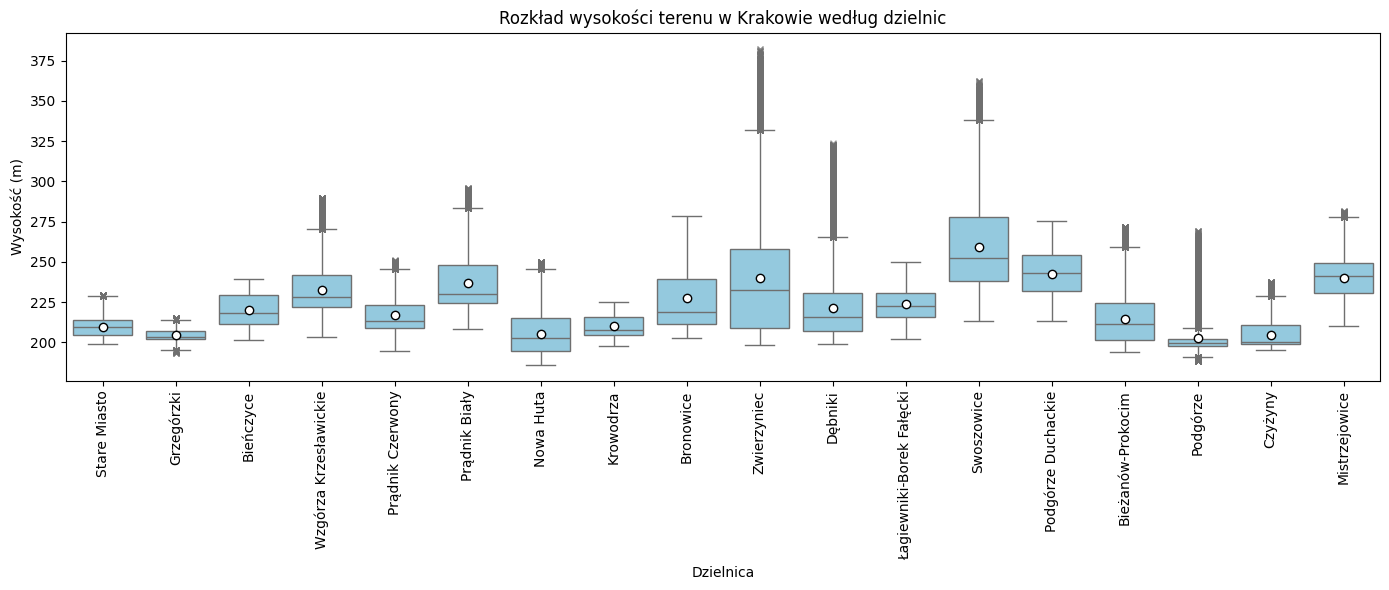

In [139]:
plt.figure(figsize=(14,6))

flier_props = dict(marker='x', color='red', markersize=4, alpha=0.5)

sns.boxplot(
    data=plot_data,
    x='Dzielnica',
    y='Wysokość',
    color='skyblue',      
    showmeans=True,      
    meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=6),
    flierprops=flier_props
)

plt.xticks(rotation=90)

plt.title('Rozkład wysokości terenu w Krakowie według dzielnic')
plt.xlabel('Dzielnica')
plt.ylabel('Wysokość (m)')

plt.tight_layout()
plt.show()

### Zadanie 6: Nachylenie terenu (6 pkt)

Bazując na zawartym w rastrze numerycznym modelu terenu przygotuj raster zawierający informacje o nachyleniu terenu wyrażonym w stopniach.

Przedstaw wynik operacji na wykresie zawierającym następujące warstwy (idąc od spodu):
- samodzielnie wybrana (inną od domyślnej) mapa podkładowa,
- raster z nachyleniem terenu wyrażonym w stopniach, samodzielnie dobraną, inną od domyślnej skalą kolorów, której zakres wartości wynosi 0-45 (argumenty `vmin` i `vmax`).
- kontury dzielnic miasta Krakowa, bez wypełnienia.

Przygotowując figurę pamiętaj o ogólnych wytycznych z nagłówka notatnika.

Schemat rozwiązania zadania:
 1) Przygotuj dwie macierze o wymiarach 3x3: </br>
    $kernel_x = \begin{bmatrix}
    -1 & 0 &  1 \\
    -2 & 0 &  2 \\
    -1 & 0 &  1 \\
    \end{bmatrix} / (8 \cdot c_x)$ </br>
    $kernel_y = \begin{bmatrix}
    -1 & -2 &  -1 \\
    0 & 0 &  0 \\
    1 & 2 &  1 \\
    \end{bmatrix} / (8 \cdot c_y)$ </br>
    gdzie $c_x$ i $c_y$ to odpowiednio rozmiar piksela rastra w poziomie i w pionie.
 2) Korzystając z funkcji `scipy.signal.convolve2d()` dokonaj konwolucji przygotowanych macierzy z rastem zawartym w zmiennej `NMT_krk`. Zwróć uwagę, że zawarta w zmiennej macierz ma 3 wymiary, a do konwolucji należy przekazać pojedynczą warstwę rastra - macierz 2D. Ustaw następujące wartości argumentów funkcji: `mode='same'` (macierz wynikowa ma ten sam rozmiar co macierz wejściowa co pozwala na skorzystanie z tej samej transformacji do georeferencji rastra), `boundary='symm'` (określa metodę obliczania wartości na granicy rastra). Wyniki konwolucji rastra z jądrami `kernel_x` i `kernel_y` zapisz odpowiednio do zmiennych `dzdx` i `dzdy`.
 3) Oblicz nachylenie terenu w radianach z wykorzystaniem funkcji `numpy.arctan()` i `numpy.sqrt()`: $slope_{rad}= arctan(\sqrt{dzdx^2 + dzdy^2})$.
 4) Przelicz nachylenie terenu do stopni korzystając z funkcji `numpy.degrees()`.

In [136]:
c_x = dataset.transform.a
c_y = dataset.transform.e

kernel_x = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
]) / (8 * c_x)

kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
]) / (8 * c_y)

dzdx = sp.signal.convolve2d(NMT_krk[0,:,:], kernel_x, mode='same', boundary='symm')
dzdy = sp.signal.convolve2d(NMT_krk[0,:,:], kernel_y, mode='same', boundary='symm')
slope_krk = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
slope_krk = np.degrees(slope_krk)

In [137]:
# Komórka testowa
assert type(slope_krk) == np.ndarray
assert np.shape(slope_krk) == (3513, 6075)
assert np.sum(np.isnan(slope_krk)) == 8315598
assert np.isclose(np.nanmin(slope_krk), 0.0)
assert np.isclose(np.nanmean(slope_krk),3.2474410044700996)
assert np.isclose(np.nanmax(slope_krk), 74.94143387523138)

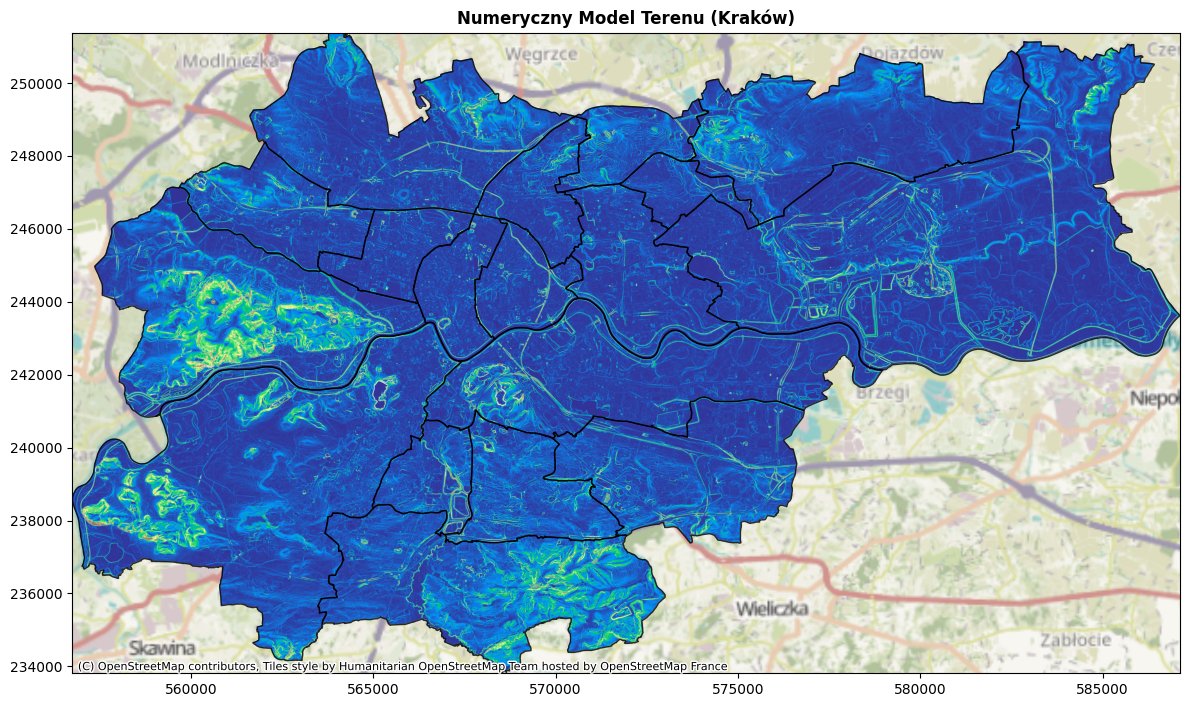

In [147]:
fig, ax = plt.subplots(figsize=(12,12))
ax.set_title("Nachylenie terenu w Krakowie", fontsize=16)

rasterio.plot.show(slope_krk, ax=ax,transform = transform_krk, cmap='terrain',
                   vmin=0, vmax=45, title="Numeryczny Model Terenu (Kraków)", zorder=2)

districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1, alpha=0.8, zorder = 3)

cx.add_basemap(
    ax, 
    crs=districts.crs.to_string(),
    zorder = 1
)


plt.tight_layout()
plt.show()